In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


Shape: (201664, 25)

Missing Values:
 datetime        0
date            0
year            0
month           0
day             0
hour            0
day_of_week     0
is_weekend      0
season          0
city            0
station         0
latitude        0
longitude       0
pm25            0
pm10            0
no2             0
so2             0
co              0
o3              0
temperature     0
humidity        0
wind_speed      0
visibility      0
aqi             0
aqi_category    0
dtype: int64

Class Distribution:
 aqi_category
Severe          60102
Moderate        45397
Satisfactory    32860
Very Poor       29674
Poor            18843
Good            14788
Name: count, dtype: int64


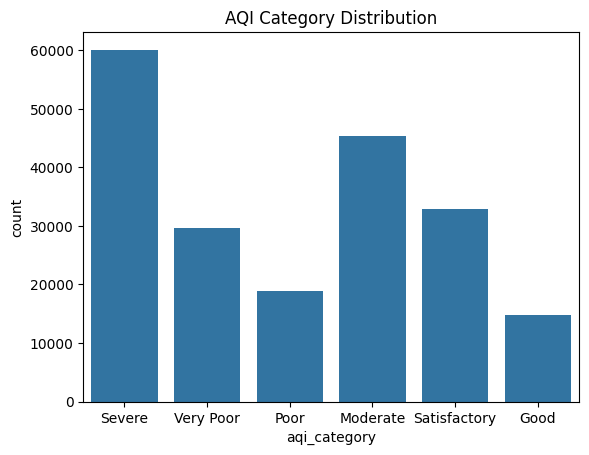

In [4]:
# Load Data
df = pd.read_csv("delhi_ncr_aqi_dataset.csv")
print("Shape:", df.shape)

# Simple EDA
print("\nMissing Values:\n", df.isnull().sum())

print("\nClass Distribution:\n", df["aqi_category"].value_counts()) # data here is imbalanced 

sns.countplot(data = df, x = "aqi_category")
plt.title("AQI Category Distribution")
plt.show()

In [5]:
# Data Cleaning
df = df.drop(columns = ["datetime", "date", "aqi"]) # We delete these columns because duplicates and data leakage  

for col in ["day_of_week", "season", "city", "station", "aqi_category"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

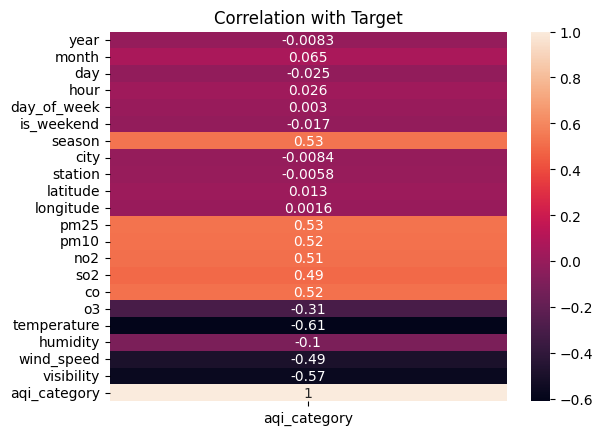

In [ ]:
# Feature Selection (Simple)
corr = df.corr()

sns.heatmap(corr[["aqi_category"]], annot = True)
plt.title("Correlation with Target")
plt.show()

features = ["pm25", "pm10", "co", "no2", "temperature", "visibility", "wind_speed", "o3"]

X = df[features]
y = df["aqi_category"]

In [12]:
# Split + Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
# stratify allows the split to maintain the same distribution of categories. train and test same samples

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # cacl mean and standard deviation and use them to avoid data leakage
X_test = scaler.transform(X_test)


# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter = 1000),
    "Decision Tree": DecisionTreeClassifier(max_depth = 10),
    "Random Forest": RandomForestClassifier(n_estimators = 100)
}


=== Logistic Regression ===
Accuracy: 0.9627848164034414
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      2958
           1       0.95      0.97      0.96      9079
           2       0.93      0.92      0.93      3769
           3       0.95      0.93      0.94      6572
           4       0.99      0.99      0.99     12020
           5       0.98      0.96      0.97      5935

    accuracy                           0.96     40333
   macro avg       0.95      0.95      0.95     40333
weighted avg       0.96      0.96      0.96     40333



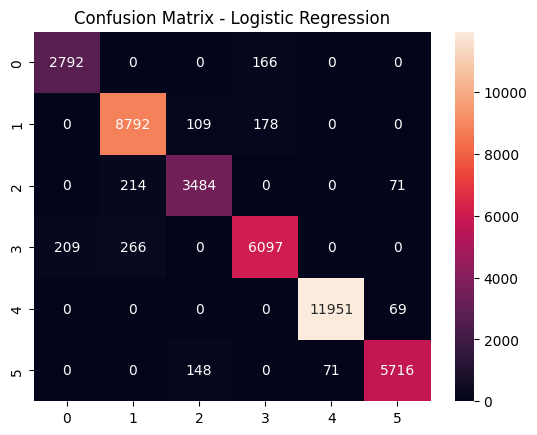


=== Decision Tree ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2958
           1       1.00      1.00      1.00      9079
           2       1.00      1.00      1.00      3769
           3       1.00      1.00      1.00      6572
           4       1.00      1.00      1.00     12020
           5       1.00      1.00      1.00      5935

    accuracy                           1.00     40333
   macro avg       1.00      1.00      1.00     40333
weighted avg       1.00      1.00      1.00     40333



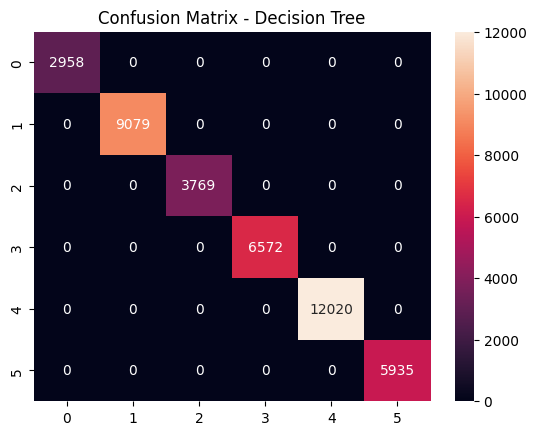


=== Random Forest ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2958
           1       1.00      1.00      1.00      9079
           2       1.00      1.00      1.00      3769
           3       1.00      1.00      1.00      6572
           4       1.00      1.00      1.00     12020
           5       1.00      1.00      1.00      5935

    accuracy                           1.00     40333
   macro avg       1.00      1.00      1.00     40333
weighted avg       1.00      1.00      1.00     40333



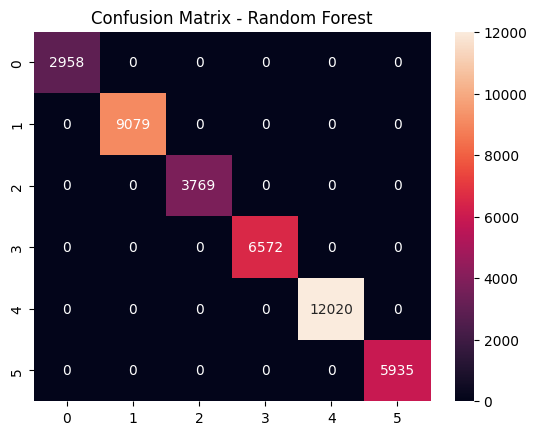

In [ ]:
# Training + Evaluation
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred)) # precision use to decrease false positive and recal for decrease false negative

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot = True, fmt = 'd')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    results.append({
        "Model": name,
        "Accuracy": acc
    })


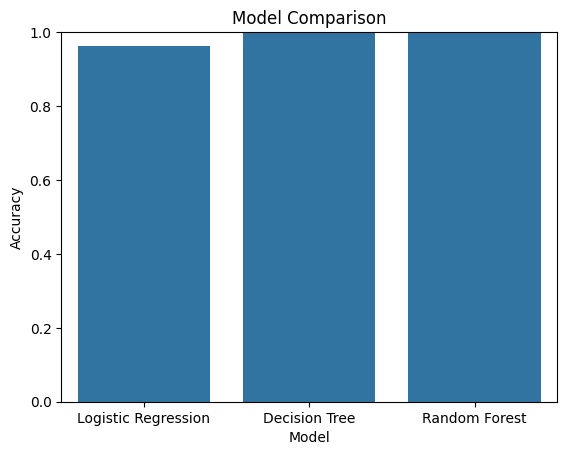

In [7]:
# Comparison
results_df = pd.DataFrame(results)

sns.barplot(data = results_df, x = "Model", y = "Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()